# The ML Process, Data, and Features

- Author: Tulsi Marshall
- Date: 2026-07
- Dataset: UCI Student Performance, student-mat.csv (Cortez, P. 2014, UCI Machine Learning Repository, https://doi.org/10.24432/C5TG7T, CC BY 4.0)
- Target: G3

Select Kernel

Run all cells top to bottom (**Run All**) before pushing to GitHub.

## Overview

This project uses the UCI Student Performance dataset.
The data covers 395 students in a secondary school mathematics course at two Portuguese schools,
with 33 columns describing demographics, family background, social life, school support, and grades.
It was collected from school reports and questionnaires by Cortez and Silva (2008).

We choose to predict the target `G3`, the student's final grade.
This target is a numeric variable (rather than a category), and it is discrete and bounded:
whole numbers from 0 to 20. The order and the spacing are meaningful, so we have a:

- supervised ML problem (because we've chosen a target)
- a regression problem (because our target is numeric)

I chose this dataset because I coordinate a learning center, and it raises a question that I
actually face: can we tell which students are heading for a poor outcome while there is
still time to reach them? That framing matters here. A feature is only useful if it carries information about the target and is available at the time of prediction, and that constraint shapes which columns can be used with the desired timeline.

## Section 1. Project Setup and Imports

In [29]:
# === Section 1a. DECLARE IMPORTS ===

from importlib.metadata import version  # to verify
import logging  # for type hinting
import platform  # to verify
from typing import Final  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("M02-STUDENTS", level="DEBUG")
log_header(LOG, "M02")

# === Section 1c. USE THE LOGGER TO VERIFY IMPORTS ===

# If any do NOT return a version number, then that package is not installed correctly.
# Check your pyproject.toml and re-run environment setup commands.

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  scikit-learn: {version('scikit-learn')}")
LOG.info(f"  seaborn:      {version('seaborn')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")


# === Section 1d. SET PANDAS DISPLAY CONFIGURATION (helps in notebooks) ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

2026-07-11 18:20:18 | INFO | M02-STUDENTS | === RUN START ===
2026-07-11 18:20:18 | INFO | M02-STUDENTS | project=M02
2026-07-11 18:20:18 | INFO | M02-STUDENTS | repo_dir=ml-02-features
2026-07-11 18:20:18 | INFO | M02-STUDENTS | python=3.14.2
2026-07-11 18:20:18 | INFO | M02-STUDENTS | os=Windows 11
2026-07-11 18:20:18 | INFO | M02-STUDENTS | shell=powershell
2026-07-11 18:20:18 | INFO | M02-STUDENTS | cwd=notebooks
2026-07-11 18:20:18 | INFO | M02-STUDENTS | github_actions=False
2026-07-11 18:20:18 | INFO | M02-STUDENTS | Confirming installation:
2026-07-11 18:20:18 | INFO | M02-STUDENTS |   python:       3.14.2
2026-07-11 18:20:18 | INFO | M02-STUDENTS |   pandas:       3.0.3
2026-07-11 18:20:18 | INFO | M02-STUDENTS |   numpy:        2.5.1
2026-07-11 18:20:18 | INFO | M02-STUDENTS |   scikit-learn: 1.9.0
2026-07-11 18:20:18 | INFO | M02-STUDENTS |   seaborn:      0.13.2
2026-07-11 18:20:18 | INFO | M02-STUDENTS |   matplotlib:   3.11.0


## Section 2. Load the Data

In [30]:
# === Section 2. Load the Data ===

# CUSTOM: This dataset is a CSV file in data/raw, downloaded from the UCI
# Machine Learning Repository. The file is semicolon-separated, so we tell
# pandas to use ";" as the separator rather than the default comma.
# Notebooks run from notebooks/, so "../" steps up to the project root.

DATASET_NAME: Final[str] = "student-mat"

LOG.info(f"Loading dataset: {DATASET_NAME}")
df: pd.DataFrame = pd.read_csv(f"../data/raw/{DATASET_NAME}.csv", sep=";")
LOG.info(f"Loaded: {df.shape[0]} rows (instances), {df.shape[1]} columns")

2026-07-11 18:20:18 | INFO | M02-STUDENTS | Loading dataset: student-mat
2026-07-11 18:20:18 | INFO | M02-STUDENTS | Loaded: 395 rows (instances), 33 columns


## Section 3. Assess the Data

Before deciding anything, we report the facts: the type of each column, how complete it is,
and the spread of the numeric columns. The code reports. The analyst decides.




In [31]:
# === Section 3. Assess the Data ===

# CUSTOM: ANALYST CHOICE - the column you intend to predict.
# Naming it now to watch for features that would leak it.

INTENDED_TARGET: Final[str] = "G3"
LOG.info(f"The intended target is '{INTENDED_TARGET}'.")
LOG.info("Any feature derived FROM the target would leak the answer. Avoid those.")


# Report facts an analyst needs to judge whether columns are useful.

# WHY: Missingness, type, and basic spread tell us whether a column can
# carry signal and whether it is populated enough to rely on.
# This code reports those facts; it does not decide which columns to keep.

LOG.info("Per-column completeness and type:")

n_rows: int = df.shape[0]

for col in df.columns:
    missing: int = int(df[col].isna().sum())
    pct_present: float = 100.0 * (n_rows - missing) / n_rows
    LOG.info(
        f"  {col:20s} {str(df[col].dtype):10s} present={pct_present:5.1f}%  missing={missing}"
    )

numeric_cols: list[str] = df.select_dtypes(include="number").columns.tolist()
LOG.info("Numeric summary (for spread / outliers):")
LOG.debug(f"\n{df[numeric_cols].describe()}")

2026-07-11 18:20:18 | INFO | M02-STUDENTS | The intended target is 'G3'.
2026-07-11 18:20:18 | INFO | M02-STUDENTS | Any feature derived FROM the target would leak the answer. Avoid those.
2026-07-11 18:20:18 | INFO | M02-STUDENTS | Per-column completeness and type:
2026-07-11 18:20:18 | INFO | M02-STUDENTS |   school               str        present=100.0%  missing=0
2026-07-11 18:20:18 | INFO | M02-STUDENTS |   sex                  str        present=100.0%  missing=0
2026-07-11 18:20:18 | INFO | M02-STUDENTS |   age                  int64      present=100.0%  missing=0
2026-07-11 18:20:18 | INFO | M02-STUDENTS |   address              str        present=100.0%  missing=0
2026-07-11 18:20:18 | INFO | M02-STUDENTS |   famsize              str        present=100.0%  missing=0
2026-07-11 18:20:18 | INFO | M02-STUDENTS |   Pstatus              str        present=100.0%  missing=0
2026-07-11 18:20:18 | INFO | M02-STUDENTS |   Medu                 int64      present=100.0%  missing=0
2026-

### A closer look before deciding

We chart `absences` because the numeric summary showed a maximum of 75 against a median of 4,
and `G3` because it is the target and its shape should inform what we expect.
`studytime` is included as a comparison, since it is already recorded as an ordered scale.

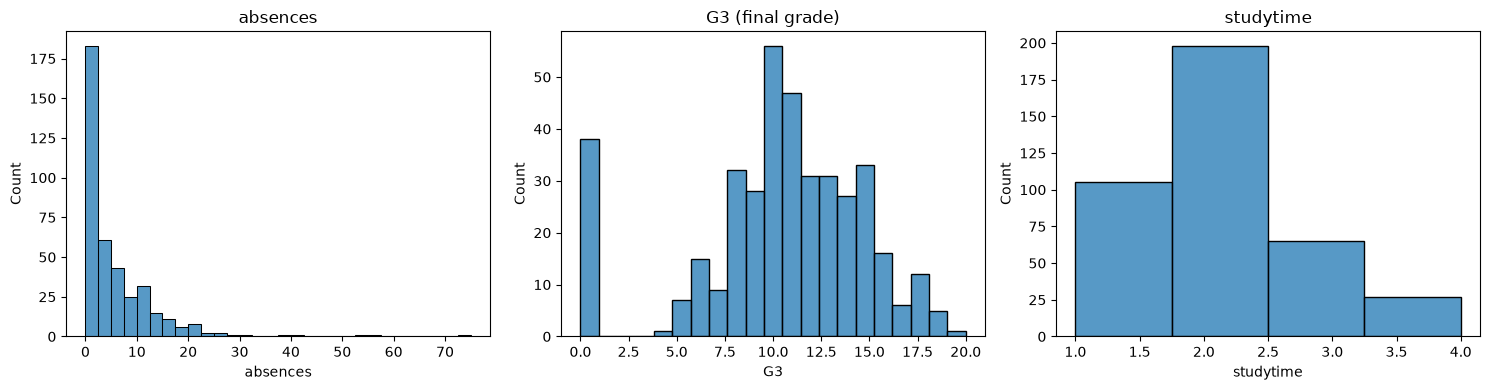

2026-07-11 18:20:19 | INFO | M02-STUDENTS | absences: max=75, median=4.0
2026-07-11 18:20:19 | INFO | M02-STUDENTS | absences over 20: 15 students
2026-07-11 18:20:19 | INFO | M02-STUDENTS | G3 equal to zero: 38 students


In [32]:
# === Look before deciding: distributions that drive feature choices ===

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df["absences"], bins=30, ax=axes[0])
axes[0].set_title("absences")

sns.histplot(df["G3"], bins=21, ax=axes[1])
axes[1].set_title("G3 (final grade)")

sns.histplot(df["studytime"], bins=4, ax=axes[2])
axes[2].set_title("studytime")

plt.tight_layout()
plt.savefig(
    "../docs/images/distributions_gracecode42.png", dpi=150, bbox_inches="tight"
)
plt.show()

LOG.info(f"absences: max={df['absences'].max()}, median={df['absences'].median()}")
LOG.info(f"absences over 20: {(df['absences'] > 20).sum()} students")
LOG.info(f"G3 equal to zero: {(df['G3'] == 0).sum()} students")

### Absences in more detail

The histogram shows a long right tail, so we look at the quartiles and the 1.5 IQR fence.
The bin boundaries used in Section 4 come from these numbers rather than from habit.

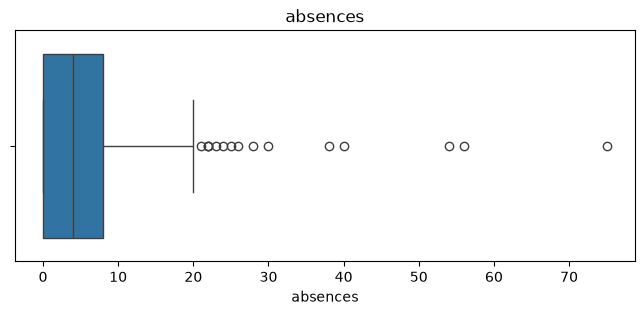

2026-07-11 18:20:19 | INFO | M02-STUDENTS | Q1=0.0, median=4.0, Q3=8.0, IQR=8.0, upper fence=20.0
2026-07-11 18:20:19 | INFO | M02-STUDENTS | absences above the fence: 15 students


In [33]:
# === Absences: box plot to see quartiles and outlier fences ===

plt.figure(figsize=(8, 3))
sns.boxplot(x=df["absences"])
plt.title("absences")
plt.show()

q1 = df["absences"].quantile(0.25)
med = df["absences"].median()
q3 = df["absences"].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr

LOG.info(f"Q1={q1}, median={med}, Q3={q3}, IQR={iqr}, upper fence={upper_fence}")
LOG.info(f"absences above the fence: {(df['absences'] > upper_fence).sum()} students")

## Section 4. Construct Features

This section makes three changes to a copy of the data. First it removes the two columns that
would not be available at the time of the prediction. Then it builds two new features:
one flag drawn from the parents' jobs, and one category drawn from the absence counts using
the boundaries found above.

2026-07-11 18:20:19 | INFO | M02-STUDENTS | Constructing features (vectorized, none are derived from the target)
2026-07-11 18:20:19 | INFO | M02-STUDENTS | Dropped features: ['G1', 'G2']
2026-07-11 18:20:19 | INFO | M02-STUDENTS | Added features: ['parent_at_home', 'absence_level']
2026-07-11 18:20:19 | DEBUG | M02-STUDENTS | Sample of constructed features:
2026-07-11 18:20:19 | DEBUG | M02-STUDENTS | 
      Mjob      Fjob  absences  parent_at_home absence_level
0  at_home   teacher         6               1      moderate
1  at_home     other         4               1      moderate
2  at_home     other        10               1          high
3   health  services         2               0           low
4    other     other         4               0      moderate


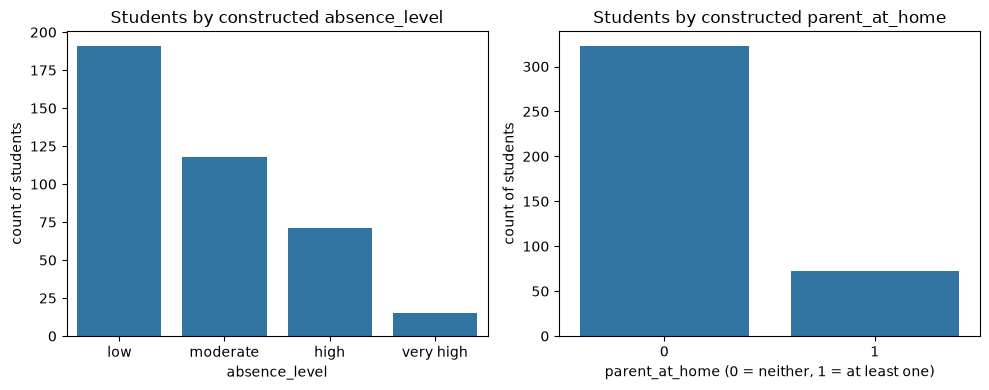

In [34]:
# === Section 4. Construct Features ===

"""Derive new features from existing columns (vectorized).

WHY: New inputs can make a real pattern easier for a model to use.
These operate on whole columns at once (no Python loop).
None of them is built from the intended target, so they cannot leak it.

Removed here:
- G1, G2: period grades, not available at the time of the prediction

Built here:
- parent_at_home: 1 if either parent's job is "at_home", else 0   (flag)
- absence_level: a category from absences                          (binned)

"""
LOG.info("Constructing features (vectorized, none are derived from the target)")

# Work on a copy so the original stays unchanged.
# Follow current pandas idiom:
# assign explicitly; avoid chained inplace, which silently does nothing
df_feat: pd.DataFrame = df.copy()

# Remove features that will not be available at prediction time.
# The use case is an early alert three weeks into the term, before any
# period grade has posted. G1 and G2 are the first and second period
# grades, so neither one exists yet at the moment the prediction is needed.
dropped_cols: list[str] = ["G1", "G2"]

df_feat = df_feat.drop(columns=dropped_cols)
LOG.info(f"Dropped features: {dropped_cols}")

# A binary flag from two categorical columns.
# Either parent at home may mean more supervision, or may mean
# financial strain. The direction is not obvious, which is worth noting.
df_feat["parent_at_home"] = (
    (df_feat["Mjob"] == "at_home") | (df_feat["Fjob"] == "at_home")
).astype(int)

# A categorical feature via binning. Bins are an ANALYST CHOICE.
# Boundaries follow the observed distribution: median = 4, Q3 = 8,
# and the 1.5 IQR upper fence = 20.
df_feat["absence_level"] = pd.cut(
    df_feat["absences"],
    bins=[-1, 3, 8, 20, np.inf],
    labels=["low", "moderate", "high", "very high"],
)

new_cols: list[str] = ["parent_at_home", "absence_level"]

LOG.info(f"Added features: {new_cols}")

LOG.debug("Sample of constructed features:")
LOG.debug(f"\n{df_feat[['Mjob', 'Fjob', 'absences', *new_cols]].head()}")

# Show the new features.
# Visualize in every project.

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(data=df_feat, x="absence_level", ax=axes[0])
axes[0].set_title("Students by constructed absence_level")
axes[0].set_xlabel("absence_level")
axes[0].set_ylabel("count of students")

sns.countplot(data=df_feat, x="parent_at_home", ax=axes[1])
axes[1].set_title("Students by constructed parent_at_home")
axes[1].set_xlabel("parent_at_home (0 = neither, 1 = at least one)")
axes[1].set_ylabel("count of students")

plt.tight_layout()
plt.savefig(
    "../docs/images/constructed_features_gracecode42.png", dpi=150, bbox_inches="tight"
)
plt.show()

## Section 5. Summary and Next Steps

In [35]:
# === Python Summary ===


"""Record where we are in the process and the judgment still owed."""
LOG.info("========================")
LOG.info("SUMMARY")
LOG.info("========================")
LOG.info(f"Dataset:          {DATASET_NAME}")
LOG.info(f"Original columns: {df.shape[1]}")
LOG.info(f"Columns removed:  {len(dropped_cols)} {dropped_cols}")
LOG.info(f"Columns added:    {len(new_cols)} {new_cols}")
LOG.info(f"After features:   {df_feat.shape[1]}")
LOG.info(f"Intended target:  {INTENDED_TARGET}")
LOG.info("========================")

2026-07-11 18:20:19 | INFO | M02-STUDENTS | ========================
2026-07-11 18:20:19 | INFO | M02-STUDENTS | SUMMARY
2026-07-11 18:20:19 | INFO | M02-STUDENTS | ========================
2026-07-11 18:20:19 | INFO | M02-STUDENTS | Dataset:          student-mat
2026-07-11 18:20:19 | INFO | M02-STUDENTS | Original columns: 33
2026-07-11 18:20:19 | INFO | M02-STUDENTS | Columns removed:  2 ['G1', 'G2']
2026-07-11 18:20:19 | INFO | M02-STUDENTS | Columns added:    2 ['parent_at_home', 'absence_level']
2026-07-11 18:20:19 | INFO | M02-STUDENTS | After features:   33
2026-07-11 18:20:19 | INFO | M02-STUDENTS | Intended target:  G3
2026-07-11 18:20:19 | INFO | M02-STUDENTS | ========================


### Custom Narrative

This is SUPERVISED learning (because the data includes a target).

The chosen target is `G3` and that is a discrete numeric variable.

Therefore, modeling this problem will use **regression**.

I started from the example notebook and applied the same process to a different dataset:
the UCI Student Performance data, with `G3` as the target. I assessed the columns for type
and completeness, looked at the distributions of `absences` and `G3` before deciding anything,
removed `G1` and `G2` because they would not be available when the prediction is needed,
and constructed two new features, `parent_at_home` and `absence_level`.

The result is a dataset with the same number of columns as it started with, but a different
composition: two removed, two added.

### Custom Conclusions

The interesting decision in this project was what to throw away.

`G1` and `G2` are the first and second period grades, and they are almost certainly the two most
predictive columns in the dataset. A model built on them would look very good. But a prediction
is only worth making if it arrives while someone can still act on it, and I am imagining an early
alert before the first period grades come out, when a learning center can proactively reach 
a student to support success. At that point, no period grade has posted. So the two best columns 
in the data were removed.

`absence_level` bins attendance into four groups, with boundaries at the
median, the third quartile, and the 1.5 IQR fence, so the boundaries come from the distribution.
Binning fits a variable where the difference between 0 and 2 absences is noise and the difference 
between 3 and 30 is a story. The cost is that most students land in "low" and only 15 reach 
"very high".

`parent_at_home` is a guess. A parent at home might mean more supervision, or it might mean
unemployment and financial strain. Those point opposite directions and I do not know which one
wins. I built it because the question seemed worth asking.

Neither constructed feature touches `G3`. One comes from `Mjob` and `Fjob`, the other from
`absences`, and all three of those exist long before a final grade does.

### Next Steps

We have assessed data and built features.

Next we will learn to fit a model.


## Task: Finalize Your README.md

Include in README.md:

- your project description
- any instructions
- your commands
- a link to key artifacts (including your executed notebook)

When done, you may delete this instruction in your custom notebook.


## Task: Finalize your docs/index.md

In your docs/index.md, include things like:

- Your target.
- Why predicting this target could be useful and for whom.
- Whether ML is a good tool for this problem and why or why not. 
- For example, would a simple rule work better?
- Which features look informative, and which look irrelevant.
- What might 'good enough' mean for this question.

Important:

- There is no threshold that answers these questions automatically.
- Use notebook, README.md, and docs/index.md to share your judgement and your ML skills.


## Task: Final Check

- `README.md` - reflects your description, instructions, commands, and links to your executed notebook.
- `docs/index.md` - reflects your project-specific updates.
- Your GitHub **About** section has a link to your hosted documentation site.
- The executed example notebook AND your custom notebook are available in `notebooks/`.
- Keep this **working example** alongside your custom work until your work has been assessed.
- Ensure your **custom notebook** introduces and narrates **your** custom project.

## Reminder: Run All before pushing to GitHub

Before saving a notebook (and running git add-commit-push), click 'Run All' to generate all outputs and display them in the notebook.

Follow our [pro-analytics-02](https://denisecase.github.io/pro-analytics-02/) common workflows.

Your README.md should have a description, a link to your executed notebook, and a list of commands (updated as you add your custom description, instructions, and commands).

Your docs/ folder should document your custom project analysis in the `docs/index.md` summary.
